In [2]:
import numpy as np
import matplotlib.pyplot as plt
import treecorr

# Multipole comparison

In [244]:
zbin1, zbin2, zbin3 = 3,4,4

In [245]:
# measurement
config =  dict(min_sep=0.5, max_sep=80, sep_units='arcmin', nbins=20, max_n=100, bin_type='LogMultipole')
ggg = treecorr.GGGCorrelation(config)
ggg.read('../../measurements/GammaMultipoleMean/ggg_zbin{}{}{}.fits'.format(zbin1,zbin2,zbin3))
# ggg.read('../../measurements/12AprDATAVECTOR_NOISY_zbin334_run10_ncut0_maxn100_nthetabins20.fits')

In [246]:
weight0 = ggg.weightr[:,:,100]

In [247]:
# theory
shape = (4,201,20,20)
real = np.loadtxt('../output/test-cosmogridc-run/des-y3-2pt-map3/natural_components/real-bin_{}_{}_{}_m.txt'.format(zbin1,zbin2,zbin3)).reshape(shape)
imag = np.loadtxt('../output/test-cosmogridc-run/des-y3-2pt-map3/natural_components/imag-bin_{}_{}_{}_m.txt'.format(zbin1,zbin2,zbin3)).reshape(shape)
gam  = (real + 1j*imag)
gam0 = np.moveaxis(gam[0], 0, -1)
gam1 = np.moveaxis(gam[1], 0, -1)
gam2 = np.moveaxis(gam[2], 0, -1)
gam3 = np.moveaxis(gam[3], 0, -1)
del real, imag, gam

In [248]:
t1 = np.loadtxt('../output/test-cosmogridc-run/des-y3-2pt-map3/natural_components/t1.txt') * (180*60/np.pi)
t2 = np.loadtxt('../output/test-cosmogridc-run/des-y3-2pt-map3/natural_components/t2.txt') * (180*60/np.pi)
M  = np.loadtxt('../output/test-cosmogridc-run/des-y3-2pt-map3/natural_components/M.txt')

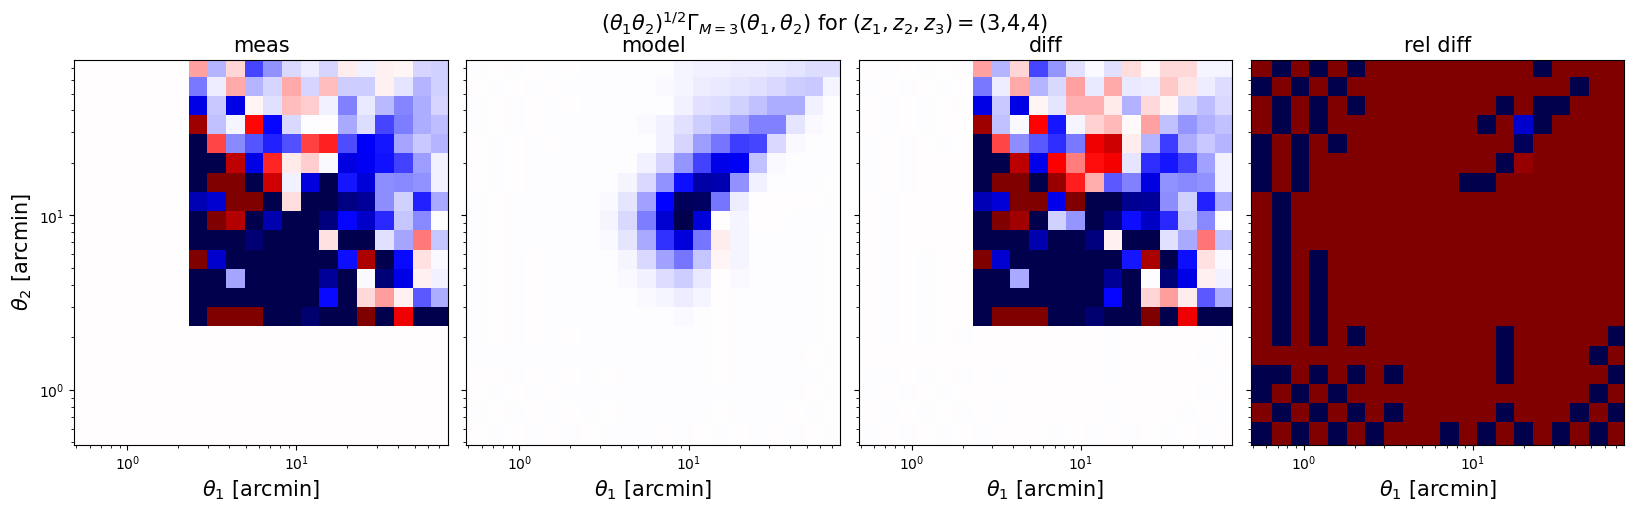

In [277]:
# values
M = 3
# meas
mask = weight0 != 0
y1 = -ggg.gam2[:,:,100+M].copy()
y1[mask] /= weight0[mask]
y1 = y1.real * 2*np.pi
# theory
y2 = gam2[:,:,100+M].real
factor = 1#(t1[:,None]*t2[None,:])**0.5
y1 = y1*factor
y2 = y2*factor
vmax = np.max([np.abs(y2).max()])
# vmax = np.max([np.abs(y1).max(), np.abs(y2).max()])
df = y1-y2
rd = df/(y1+vmax*1e-10)
# figure
fig, axes = plt.subplots(1, 4, figsize=(20,5), sharex=True, sharey=True)
fig.suptitle(r'$(\theta_1\theta_2)^{{1/2}}\Gamma_{{M={}}}(\theta_1, \theta_2)$ for $(z_1,z_2,z_3)=$({},{},{})'.format(M, zbin1, zbin2, zbin3), fontsize=15)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
# scale
axes[0].set_xscale('log')
axes[0].set_yscale('log')
# plot
axes[0].pcolormesh(t1, t2, y1, vmin=-vmax, vmax=vmax, cmap='seismic')
axes[1].pcolormesh(t1, t2, y2, vmin=-vmax, vmax=vmax, cmap='seismic')
axes[2].pcolormesh(t1, t2, df, vmin=-vmax, vmax=vmax, cmap='seismic')
axes[3].pcolormesh(t1, t2, rd, vmin=-0.1 , vmax=0.1 , cmap='seismic')
# axes[0].pcolormesh(t1, t2, y1, cmap='seismic')
# axes[1].pcolormesh(t1, t2, y2, cmap='seismic')
# axes[2].pcolormesh(t1, t2, df, cmap='seismic')
# axes[3].pcolormesh(t1, t2, rd, cmap='seismic')
# labels
for i in range(4):
    axes[i].set_xlabel(r'$\theta_1$ [arcmin]', fontsize=15) 
axes[0].set_ylabel(r'$\theta_2$ [arcmin]', fontsize=15)
# titles
axes[0].set_title('meas', fontsize=15) 
axes[1].set_title('model', fontsize=15) 
axes[2].set_title('diff', fontsize=15) 
axes[3].set_title('rel diff', fontsize=15)
plt.show()

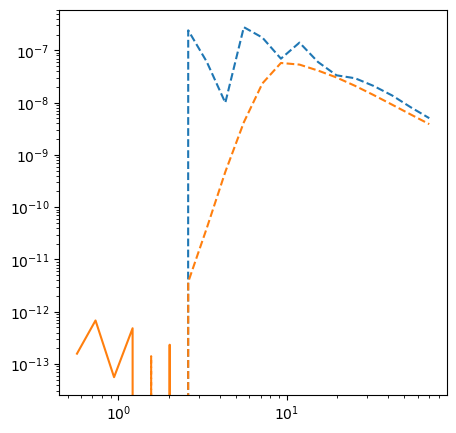

In [278]:
z1 = np.diag(y1)
z2 = np.diag(y2)

fig, ax = plt.subplots(1, 1, figsize=(5,5))
ax.set_xscale('log')
ax.set_yscale('log')
ax.plot(t1, z1, 'C0-')
ax.plot(t1,-z1, 'C0--')
ax.plot(t1, z2, 'C1-')
ax.plot(t1,-z2, 'C1--')
plt.show()

# SAS comparison

In [279]:
zbin1, zbin2, zbin3 = 3,4,4

In [376]:
sas = ggg.toSAS(phi_bin_size=0.05)
print(sas.gam0.shape, sas.gam1.shape, sas.gam2.shape, sas.gam3.shape)

# theory
shape = (4,63,20,20)
real = np.loadtxt('../output/test-cosmogridc-run/des-y3-2pt-map3/natural_components/real-bin_{}_{}_{}.txt'.format(zbin1,zbin2,zbin3)).reshape(shape)
imag = np.loadtxt('../output/test-cosmogridc-run/des-y3-2pt-map3/natural_components/imag-bin_{}_{}_{}.txt'.format(zbin1,zbin2,zbin3)).reshape(shape)
gam  = (real + 1j*imag)
gam0 = np.moveaxis(gam[0], 0, -1)
gam1 = np.moveaxis(gam[1], 0, -1)
gam2 = np.moveaxis(gam[2], 0, -1)
gam3 = np.moveaxis(gam[3], 0, -1)
del real, imag, gam
print(gam0.shape, gam1.shape, gam2.shape, gam3.shape)

(20, 20, 63) (20, 20, 63) (20, 20, 63) (20, 20, 63)
(20, 20, 63) (20, 20, 63) (20, 20, 63) (20, 20, 63)


58.57142857142858


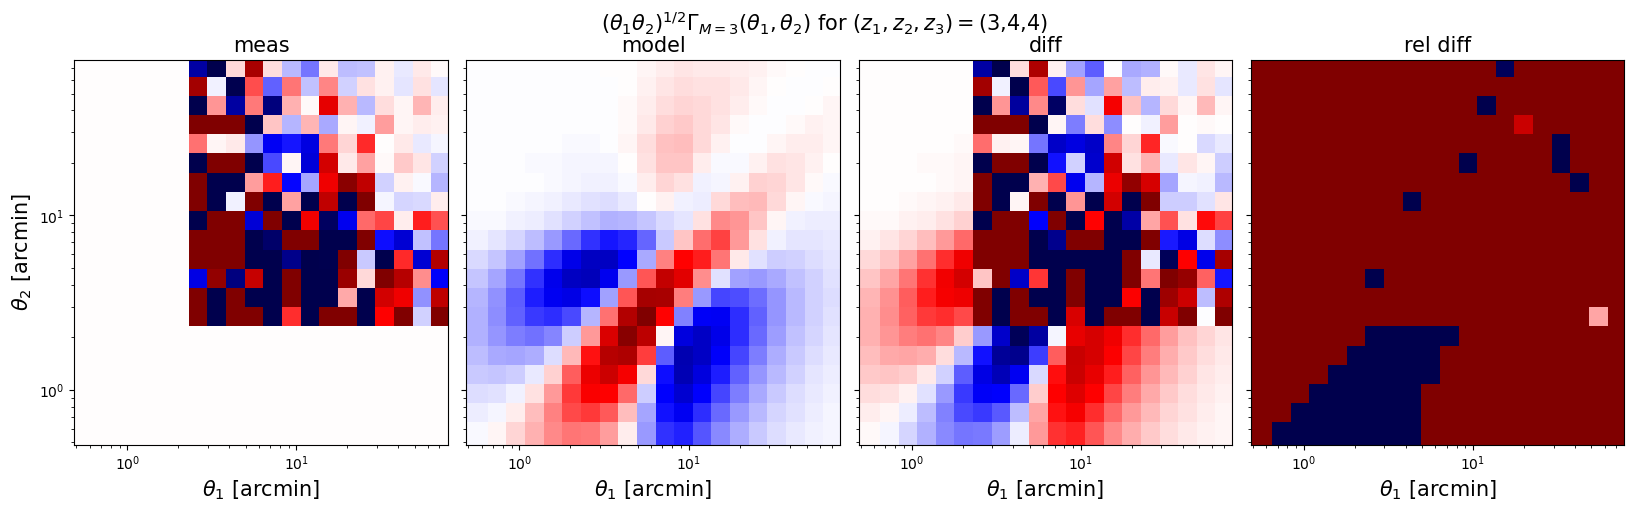

In [377]:
idx  = 20
print(np.rad2deg(sas.phi1d[idx]))
y1= -sas.gam3[:,:,idx].imag
y2 = gam3[:,:,idx].imag
df = y1-y2
rd = df/(y1+vmax*1e-10)
vmax = np.max([np.abs(y2).max()])

# figure
fig, axes = plt.subplots(1, 4, figsize=(20,5), sharex=True, sharey=True)
fig.suptitle(r'$(\theta_1\theta_2)^{{1/2}}\Gamma_{{M={}}}(\theta_1, \theta_2)$ for $(z_1,z_2,z_3)=$({},{},{})'.format(M, zbin1, zbin2, zbin3), fontsize=15)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
# scale
axes[0].set_xscale('log')
axes[0].set_yscale('log')
# plot
axes[0].pcolormesh(t1, t2, y1, vmin=-vmax, vmax=vmax, cmap='seismic')
axes[1].pcolormesh(t1, t2, y2, vmin=-vmax, vmax=vmax, cmap='seismic')
axes[2].pcolormesh(t1, t2, df, vmin=-vmax, vmax=vmax, cmap='seismic')
axes[3].pcolormesh(t1, t2, rd, vmin=-0.1 , vmax=0.1 , cmap='seismic')
# axes[0].pcolormesh(t1, t2, y1, cmap='seismic')
# axes[1].pcolormesh(t1, t2, y2, cmap='seismic')
# axes[2].pcolormesh(t1, t2, df, cmap='seismic')
# axes[3].pcolormesh(t1, t2, rd, cmap='seismic')
# labels
for i in range(4):
    axes[i].set_xlabel(r'$\theta_1$ [arcmin]', fontsize=15) 
axes[0].set_ylabel(r'$\theta_2$ [arcmin]', fontsize=15)
# titles
axes[0].set_title('meas', fontsize=15) 
axes[1].set_title('model', fontsize=15) 
axes[2].set_title('diff', fontsize=15) 
axes[3].set_title('rel diff', fontsize=15)
plt.show()

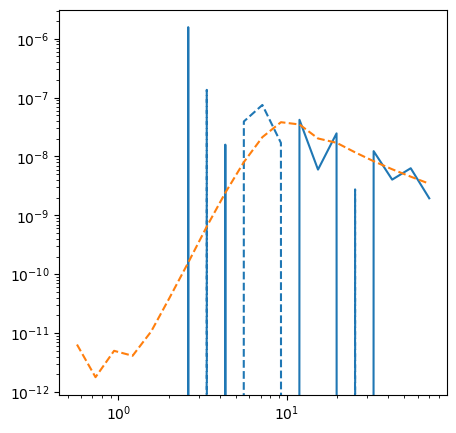

In [293]:
z1 = np.diag(y1)
z2 = np.diag(y2)

fig, ax = plt.subplots(1, 1, figsize=(5,5))
ax.set_xscale('log')
ax.set_yscale('log')
ax.plot(t1, z1, 'C0-')
ax.plot(t1,-z1, 'C0--')
ax.plot(t1, z2, 'C1-')
ax.plot(t1,-z2, 'C1--')
plt.show()

In [166]:
t1[z1 == 0].max()

2.018845436534291

In [167]:
z1

array([-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -9.94823714e-07,  7.54652633e-08,
        1.88104902e-08,  2.87018380e-08, -1.47864241e-08, -1.66164797e-10,
       -2.34702246e-08, -1.63053203e-08, -7.78513142e-09, -8.20075338e-09,
       -4.83145254e-09, -3.45451721e-09, -1.51554713e-09, -9.54298302e-10])

In [137]:
sas = ggg.toSAS(phi_bin_size=0.05)
R = np.array([7, 14, 25, 40])
map3_1 = sas.calculateMap3(R=R)[0] # average Gamma, toSAS, map3

In [138]:
map3_3 = np.loadtxt('../../measurements/GammaMultipoleMean/map3_zbin{}{}{}-3.dat'.format(zbin1, zbin2, zbin3)) # toSAS, map3, average, using Gamma files (sometimes not 400)
map3_4 = np.loadtxt('../../measurements/GammaMultipoleMean/map3_zbin{}{}{}-4.dat'.format(zbin1, zbin2, zbin3)) # toSAS, map3, average, using map3 files geenrated by Rafael's code (400).

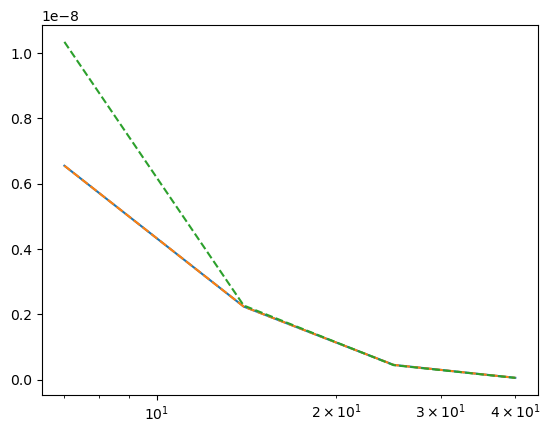

In [139]:
plt.xscale('log')
# plt.yscale('log')
plt.plot(R,-map3_1)
plt.plot(R,-map3_3, '--')
plt.plot(R,-map3_4, '--')
plt.show()

In [140]:
base = ggg.copy()
base._z1 = gam0.real
base._z2 = gam0.imag
base._z3 = gam1.real
base._z4 = gam1.imag
base._z5 = gam2.real
base._z6 = gam2.imag
base._z7 = gam3.real
base._z8 = gam3.imag
sasb = base.toSAS(phi_bin_size=0.05)
map3_t = sasb.calculateMap3(R=R)[0]

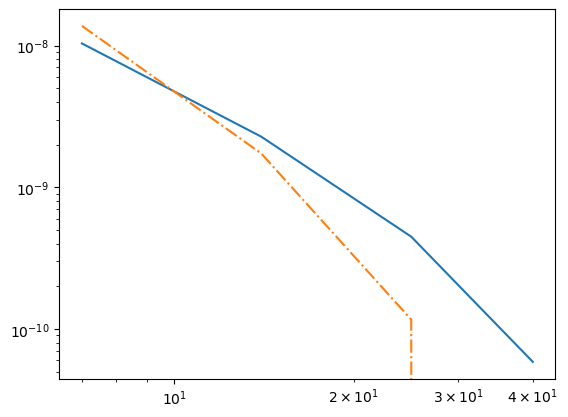

In [144]:
plt.xscale('log')
plt.yscale('log')
plt.plot(R,-map3_4, '-')
plt.plot(R, map3_t*2e3, '-.')
plt.show()

In [18]:
-map3_1/map3_t

array([  104.10529216,  2485.38954433,  7936.89367094, -5253.17194241])